In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 視覺化設定 ---
%matplotlib inline
# 設定中文字體 (Windows 使用微軟正黑體，Mac 使用 Arial Unicode MS)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False # 解決負號變方塊的問題
sns.set_theme(style="whitegrid", font=["Microsoft JhengHei", "Arial Unicode MS"])

# --- 讀取資料 ---
df_a = pd.read_csv("104_113edu_A_1_9.csv")
df_b32 = pd.read_csv("edu_B_3_2.csv")
df_b38 = pd.read_csv("edu_B_3_8.csv")

In [ ]:
# --- 資料清洗與特徵處理 (全學年度) ---

# 拆成縣市、國籍
df_a_city = df_a[df_a["國籍別/縣市別"].str.startswith("縣市別")].copy()
df_a_city["縣市別"] = df_a_city["國籍別/縣市別"].str.replace("縣市別", "", regex=False)
df_a_city["國小總人數"] = df_a_city["國小男小計"] + df_a_city["國小女小計"]
df_a_city["國中總人數"] = df_a_city["國中男小計"] + df_a_city["國中女小計"]

df_a_country = df_a[df_a["國籍別/縣市別"].str.startswith("國籍別")].copy()
df_a_country["國籍別"] = df_a_country["國籍別/縣市別"].str.replace("國籍別", "", regex=False)
df_a_country["國小總人數"] = df_a_country["國小男小計"] + df_a_country["國小女小計"]
df_a_country["國中總人數"] = df_a_country["國中男小計"] + df_a_country["國中女小計"]
df_a_country["總數"] = df_a_country["國小總人數"] + df_a_country["國中總人數"]

# 排除不必要欄位
exclude_list = ['總計', '臺灣地區', '福建省', '金馬地區', '臺閩地區']
df_b32 = df_b32[~df_b32["縣市別"].isin(exclude_list)].copy()

df_b38 = df_b38.rename(columns={'學校所在地別': '縣市別'})
df_b38 = df_b38[~df_b38["縣市別"].isin(exclude_list)].copy()

# 計算生師比、小校比例等特徵
df_b32["國小生師比"] = df_b32["學生數"] / df_b32["教師數"]
df_b32["國小小校比例"] = df_b32["12班以下校數"] / df_b32["校數"]
df_b32["國小公立比例"] = df_b32["公立學生數"] / df_b32["學生數"]

df_b38["國中生師比"] = df_b38["學生總數"] / df_b38["教師總數"]
df_b38["國中小校比例"] = df_b38["6班以下校數"] / df_b38["校數總數"]
df_b38["國中公立比例"] = df_b38["公立學生數"] / df_b38["學生總數"]

# 合併為 df_master (包含所有學年度)
df_master = pd.merge(df_a_city, df_b32, on=["學年度", "縣市別"], how="left")
df_master = pd.merge(
    df_master,
    df_b38,
    on=["學年度", "縣市別"],
    how="left",
    suffixes=("_國小", "_國中")
)

# 建立核心指標
df_master["留存率"] = df_master["國中總人數"] / df_master["國小總人數"]
df_master["國小畢業穩定度"] = df_master["上學年畢業生數"] / (df_master["學生數"] / 6)
df_master["國中畢業穩定度"] = df_master["上學年畢業生總數"] / (df_master["學生總數"] / 3)

# 移除特徵計算後的空值
df_master = df_master.dropna(subset=[
    "縣市別", "留存率", "國小畢業穩定度", "國中畢業穩定度", 
    "國小生師比", "國小小校比例", "國小公立比例"
])

print("所有年份資料合併完成！全資料大小:", df_master.shape)

display(df_master.head(3))

所有年份資料合併完成！全資料大小: (220, 50)


,學年度,國籍別/縣市別,幼兒園男小計,幼兒園女小計,國小男小計,國小女小計,國中男小計,國中女小計,縣市別,國小總人數,...,學生總數,公立學生數_國中,上學年畢業生總數,公立上學年畢業生總數,國中生師比,國中小校比例,國中公立比例,留存率,國小畢業穩定度,國中畢業穩定度
0,104,縣市別新北市,0,0,12495,11197,5699,5756,新北市,23692,...,116039,99774,41560,36101,17.767417,0.064516,0.859832,0.483497,1.104550,1.074466
1,104,縣市別臺北市,0,0,4790,4362,2355,2318,臺北市,9152,...,75015,63960,28131,24662,14.034612,0.032787,0.852629,0.510599,1.115412,1.125015
2,104,縣市別桃園市,0,0,8200,7343,4409,4208,桃園市,15543,...,76299,69052,27821,25530,13.832306,0.017241,0.905018,0.554397,1.115646,1.093894


findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

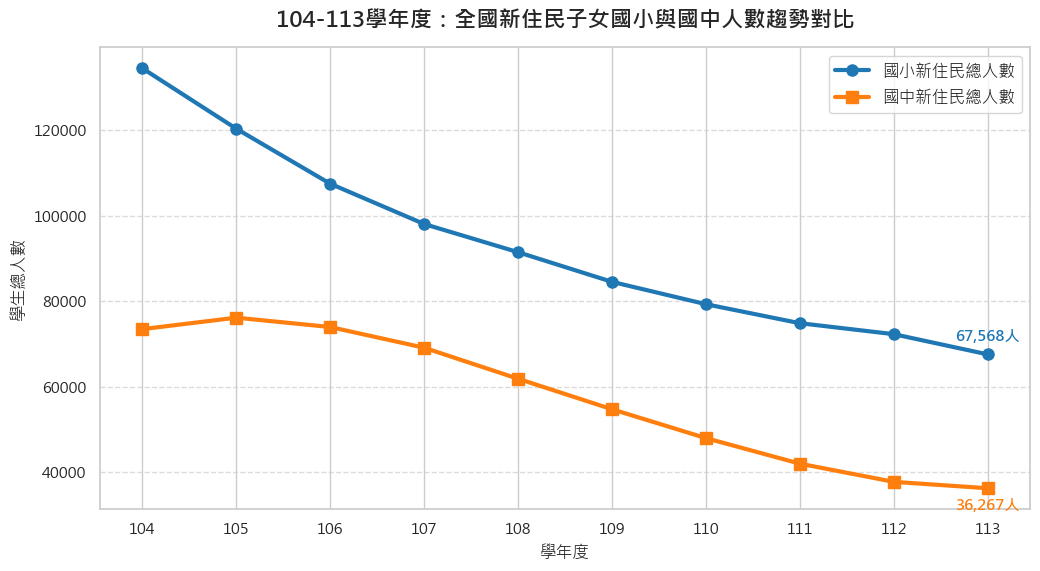

In [ ]:
# -- 繪製 全國趨勢線圖 --

plt.figure(figsize=(12, 6))

# 將各縣市人數加總，得到全國各年度總人數
trend_data = df_master.groupby('學年度')[['國小總人數', '國中總人數']].sum().reset_index()

# 繪製折線圖
plt.plot(trend_data['學年度'], trend_data['國小總人數'], marker='o', linewidth=3, markersize=8, color='#1f77b4', label='國小新住民總人數')
plt.plot(trend_data['學年度'], trend_data['國中總人數'], marker='s', linewidth=3, markersize=8, color='#ff7f0e', label='國中新住民總人數')

# 圖表美化
plt.title('104-113學年度：全國新住民子女國小與國中人數趨勢對比', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('學年度', fontsize=12)
plt.ylabel('學生總人數', fontsize=12)
plt.xticks(trend_data['學年度'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# 在圖上標註最新一年的數據
last_year = trend_data['學年度'].max()
last_elem = trend_data[trend_data['學年度']==last_year]['國小總人數'].values[0]
last_jh = trend_data[trend_data['學年度']==last_year]['國中總人數'].values[0]
plt.annotate(f"{last_elem:,}人", (last_year, last_elem), textcoords="offset points", xytext=(0,10), ha='center', fontsize=11, color='#1f77b4', fontweight='bold')
plt.annotate(f"{last_jh:,}人", (last_year, last_jh), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=11, color='#ff7f0e', fontweight='bold')

plt.show()

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

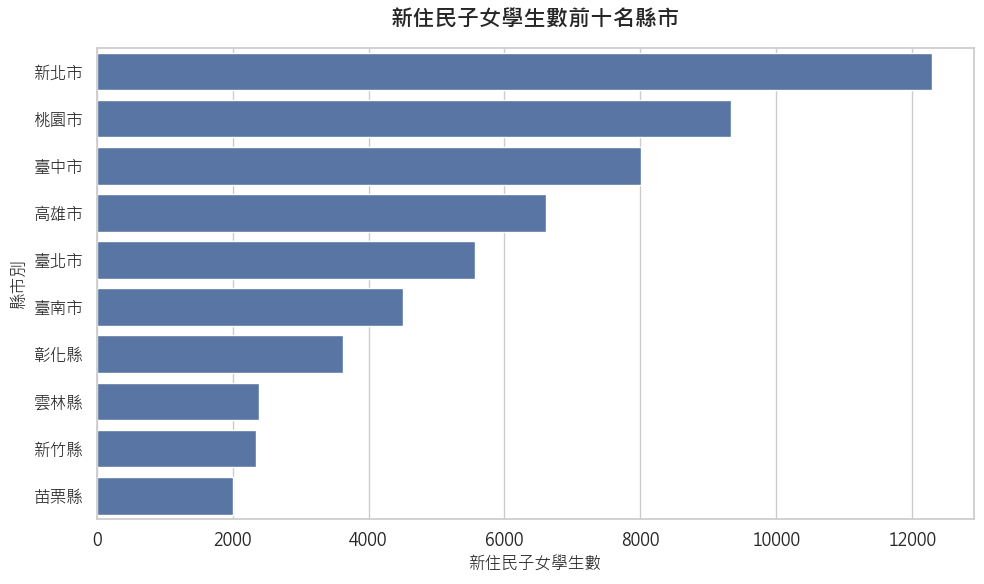

In [74]:
# 使用資料集最新年度 (113年度) 準備後續分析
latest_year = df_master['學年度'].max()
df_latest = df_master[df_master['學年度'] == latest_year].copy()


# -- 繪製 新住民學生數 Top 10 --
top10 = df_latest.sort_values("國小總人數", ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top10, x="國小總人數", y="縣市別")

plt.title("新住民子女學生數前十名縣市", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("新住民子女學生數", fontsize=12)
plt.ylabel("縣市別", fontsize=12)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig("figure1_new_resident_top10.png", dpi=300)
plt.show()

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

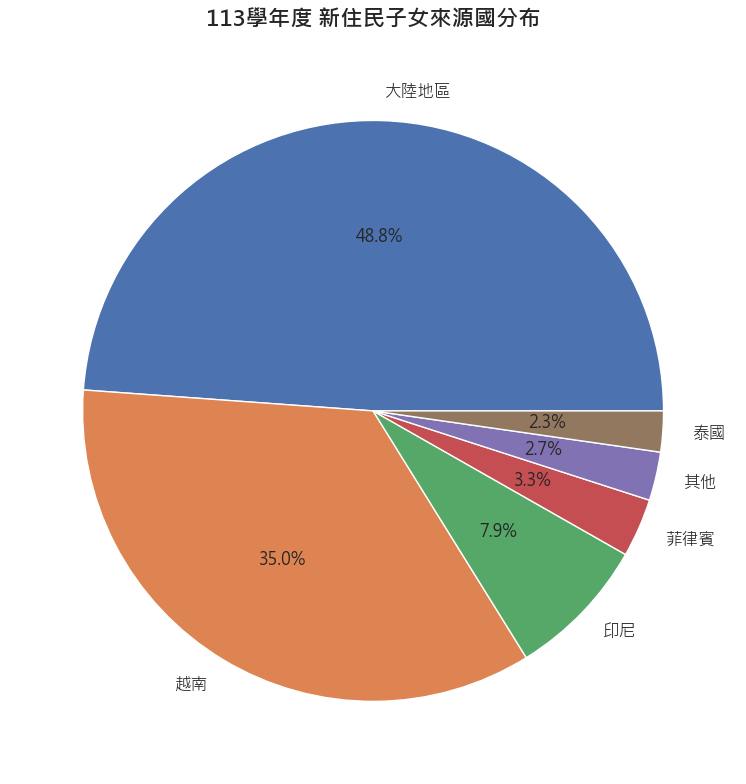

In [ ]:
# 先從來源國資料表 (df_a_country) 篩選出最新年度 (例如 113) 的資料
latest_year = df_master['學年度'].max()
df_country_latest = df_a_country[df_a_country['學年度'] == latest_year].copy()

# -- 繪製 來源國比例圖 --
top_country = df_country_latest.sort_values("總數", ascending=False).head(6)

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    top_country["總數"],
    labels=top_country["國籍別"],
    autopct="%1.1f%%"
)

plt.title(f"{latest_year}學年度 新住民子女來源國分布", fontsize=16, fontweight='bold', pad=15)

for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(12)

plt.tight_layout()
plt.savefig("figure5_nationality_pie.png", dpi=300)
plt.show()

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

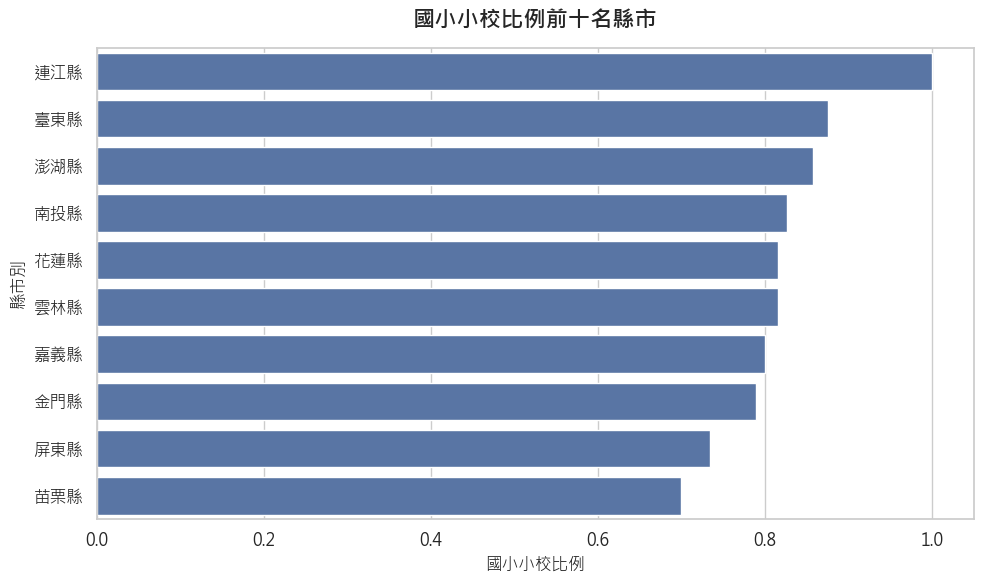

In [ ]:
# -- 繪製 小校比例 Top 10 --
small_top10 = df_latest.sort_values("國小小校比例", ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=small_top10, x="國小小校比例", y="縣市別")

plt.title("國小小校比例前十名縣市", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("國小小校比例", fontsize=12)
plt.ylabel("縣市別", fontsize=12)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig("figure6_small_school_top10.png", dpi=300)
plt.show()

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

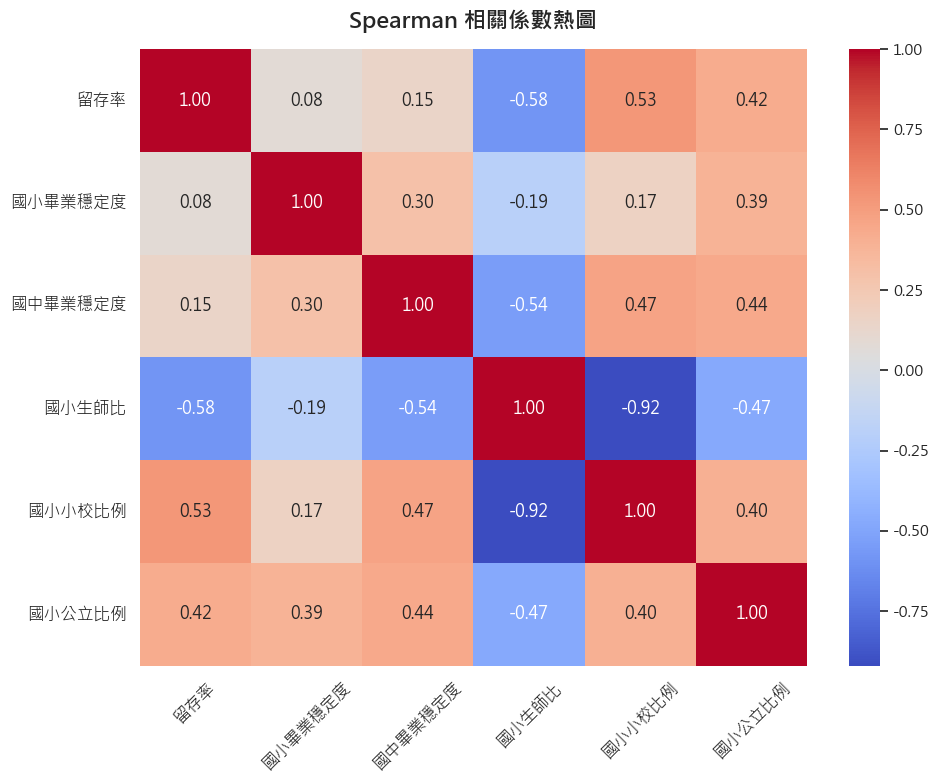

In [ ]:
# -- 繪製 Spearman 相關係數熱圖 --
corr_cols = [
    "留存率", "國小畢業穩定度", "國中畢業穩定度",
    "國小生師比", "國小小校比例", "國小公立比例"
]
corr_matrix = df_latest[corr_cols].corr(method="spearman")

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    xticklabels=corr_cols,
    yticklabels=corr_cols,
    annot_kws={"size": 12}
)

plt.title("Spearman 相關係數熱圖", fontsize=16, fontweight='bold', pad=15)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.savefig("figure2_correlation_heatmap.png", dpi=300)
plt.show()

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

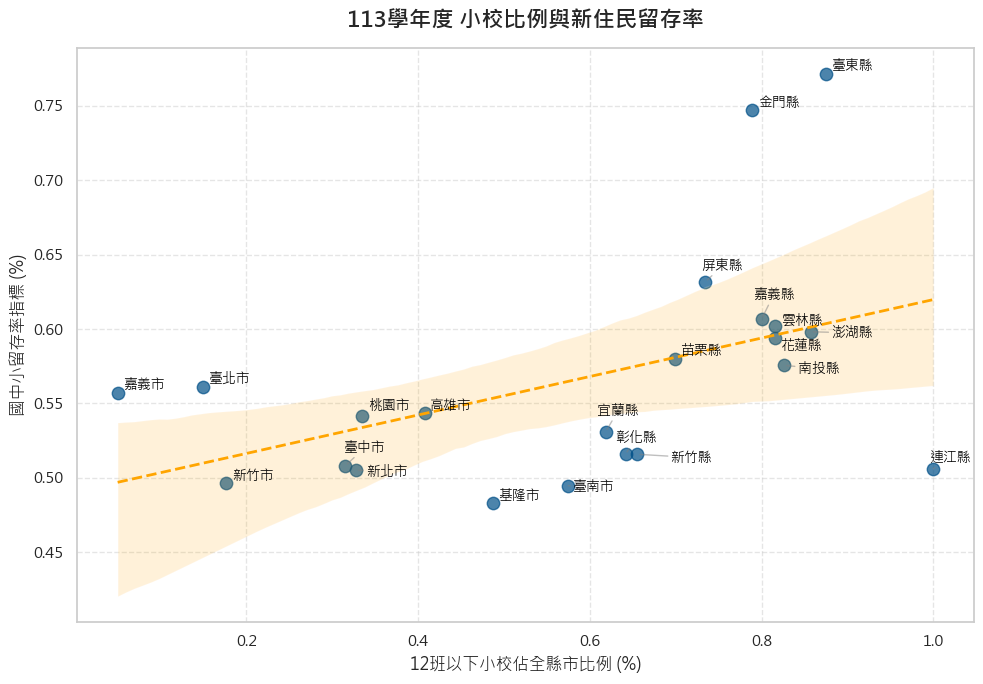

In [ ]:
# -- 繪製 偏鄉小校比例 vs 留存率 (顯示所有縣市) --
from adjustText import adjust_text

plt.figure(figsize=(10, 7))

# 繪製散佈圖與迴歸趨勢線
sns.regplot(data=df_latest, x='國小小校比例', y='留存率', 
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': '#005088'}, 
            line_kws={'color': 'orange', 'linestyle': '--', 'linewidth': 2})

# 把所有的點都加上名字
texts = []
for i in range(df_latest.shape[0]):
    t = plt.text(df_latest['國小小校比例'].iloc[i], 
                 df_latest['留存率'].iloc[i], 
                 df_latest['縣市別'].iloc[i], 
                 fontsize=10, color='black')
    texts.append(t)

# 使用 adjustText 自動推開重疊的文字，並加上指示線
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=1, alpha=0.5))

plt.title(f'{latest_year}學年度 小校比例與新住民留存率', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('12班以下小校佔全縣市比例 (%)', fontsize=12)
plt.ylabel('國中小留存率指標 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

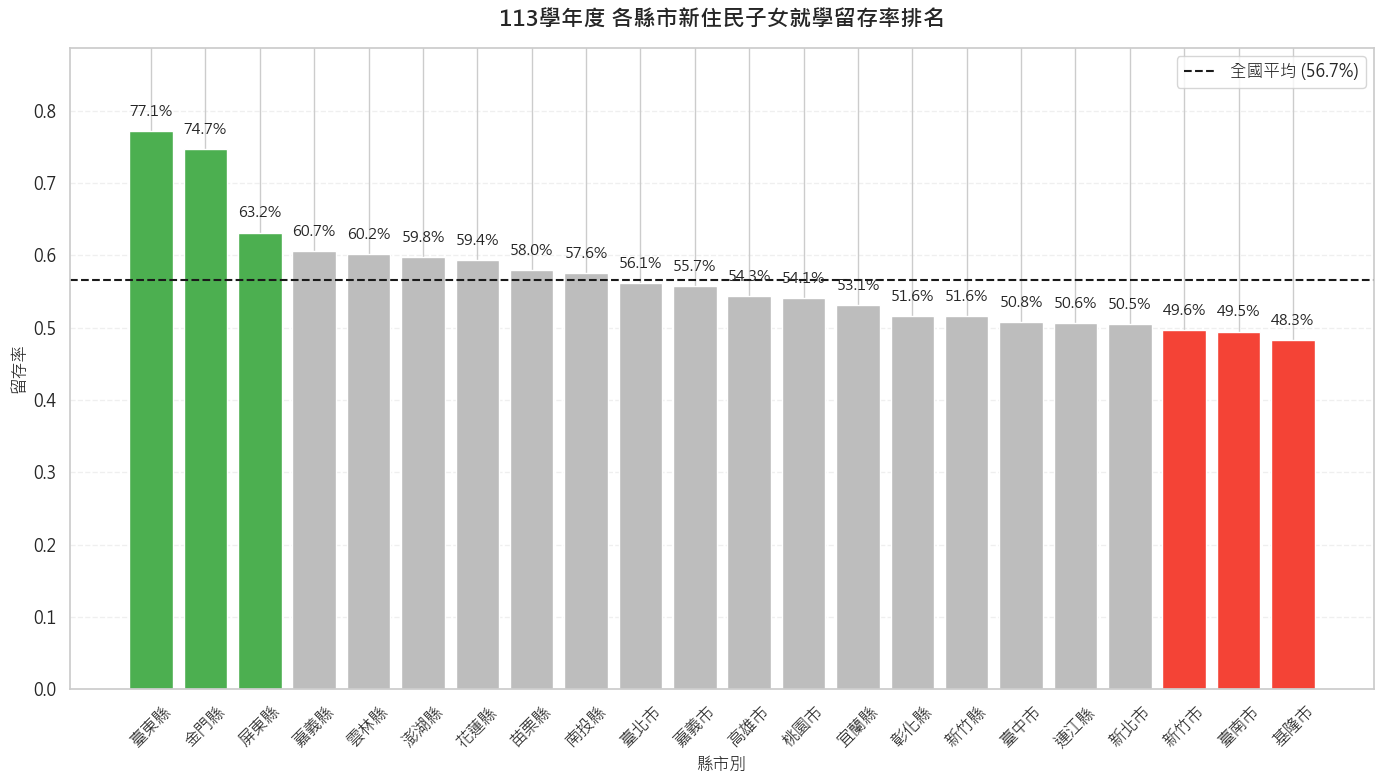

In [ ]:
# -- 繪製 市留存率排序長條圖 -- 
plt.figure(figsize=(14, 8))

df_sorted = df_latest.sort_values('留存率', ascending=False).reset_index(drop=True)

# 設定長條圖顏色：前三名綠色 (表現佳)，後三名紅色 (需注意)，其餘灰色
colors = ['#4CAF50'] * 3 + ['#BDBDBD'] * (len(df_sorted) - 6) + ['#F44336'] * 3

bars = plt.bar(df_sorted['縣市別'], df_sorted['留存率'], color=colors)
max_y = df_sorted['留存率'].max()

# 在長條圖上方標註數值
for bar in bars:
    yval = bar.get_height()
    display_val = yval * 100 if max_y <= 2 else yval
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max_y * 0.02), 
             f'{display_val:.1f}%', ha='center', va='bottom', fontsize=11)

# 畫一條全國平均基準線
avg_retention = df_latest['留存率'].mean()
display_avg = avg_retention * 100 if max_y <= 2 else avg_retention

plt.axhline(y=avg_retention, color='#1A1A1A', linestyle='--', linewidth=1.5, 
            label=f'全國平均 ({display_avg:.1f}%)')

plt.title(f'{latest_year}學年度 各縣市新住民子女就學留存率排名', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('縣市別', fontsize=12)
plt.ylabel('留存率', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 留出頂部 15% 的空間給上方的文字，避免被裁切
plt.ylim(0, max_y * 1.15)

# 緊湊佈局避免 X 軸標籤被裁切
plt.tight_layout()
plt.show()

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

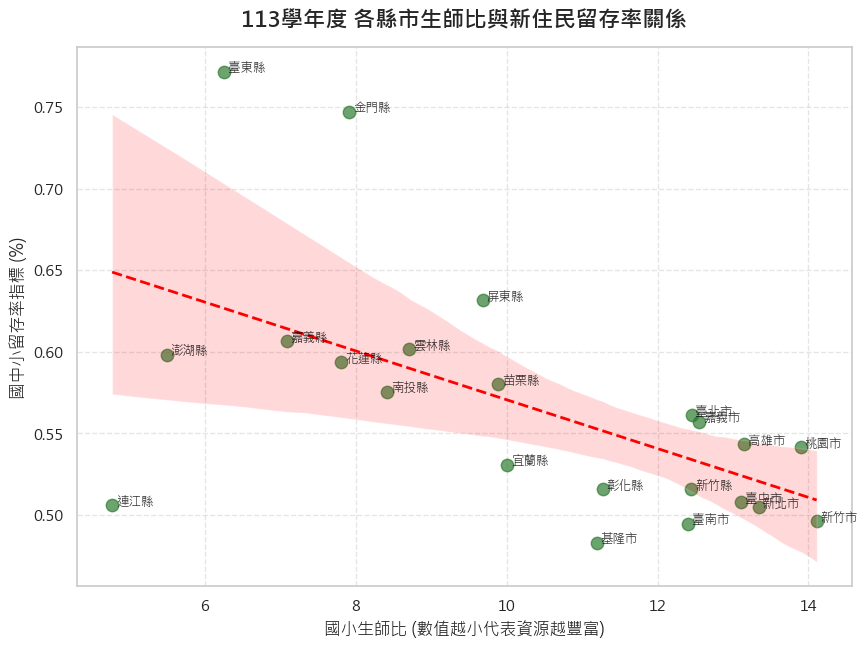

In [ ]:
# -- 繪製 資源 vs. 留存率散佈圖 --

plt.figure(figsize=(10, 7))

# 繪製散佈圖與迴歸趨勢線
sns.regplot(data=df_latest, x='國小生師比', y='留存率', 
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': '#2E7D32'}, 
            line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2})

# 幫每個點標上縣市名稱
for i in range(df_latest.shape[0]):
    plt.text(df_latest['國小生師比'].iloc[i] + 0.05, 
             df_latest['留存率'].iloc[i], 
             df_latest['縣市別'].iloc[i], 
             fontsize=9, color='black', alpha=0.8)

plt.title(f'{latest_year}學年度 各縣市生師比與新住民留存率關係', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('國小生師比 (數值越小代表資源越豐富)', fontsize=12)
plt.ylabel('國中小留存率指標 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()